# QDF 이중 태스크 학습이 3DGCL 정확도에 기여하는 방법

## 개요

```
┌─────────────────────────────────────────────────────────────────┐
│                    전체 파이프라인                               │
│                                                                 │
│  [QM9 분자] ──► [QDF 이중 태스크 학습 (E+V)] ──► [QDF 체크포인트] │
│                        ↓ 에너지 예측 (더 정확)                  │
│  [ESOL 분자] ──► [MMFF 컨포머 좌표] ──► [QDF 추론] ──► [aux .pt]│
│                                                                 │
│  [ESOL 그래프] + [aux .pt] ──► [3DGCL 대조 사전학습]            │
│                  λ × MSE(인코더 임베딩, QDF 에너지)              │
│                        ↓                                        │
│                [미세 조정] ──► ESOL RMSE ↓ (정확도 향상)         │
└─────────────────────────────────────────────────────────────────┘
```

### 왜 E+V 이중 태스크가 중요한가?

1. **E-only 학습**: QDF가 에너지만 예측 → 표현이 에너지 예측에 편향
2. **E+V 이중 태스크 학습**: 
   - E 태스크: 에너지 직접 예측
   - V 태스크 (HK map): 전자밀도 → 포텐셜 예측 (물리적 정규화)
   - 결과: **더 정확하고 물리적으로 일관된 에너지 예측**
3. **3DGCL에 미치는 영향**: 더 정확한 QDF 예측값 → 더 좋은 보조 감독 신호 → 더 좋은 분자 표현 → 더 낮은 RMSE

### 이 노트북에서 하는 실험

| 조건 | QDF Aux 손실 | λ | 비고 |
|------|----------------|---|------|
| A: 기준선 | 없음 | 0 | **B와 동일 SMILES 부분집합**으로만 사전학습 (공정 비교) |
| B: QDF 보조 | z-score 에너지 | `LAMBDA_QDF`(기본 0.03) | 동일 부분집합 + `λ·MSE` |

> **10분 예산**: `N_FOLDS=1`, 에포크 상한·큰 배치·`MMFFRANDOM_FAST`·`Finetune.evaluate` 직접 호출로 맞춤. `SUBSET_MAX`를 (ESOL∩aux) 교집합 크기 이상으로 두면 QDF 라벨 분자를 빠짐없이 사용합니다.  
> E-only vs E+V QDF 체크포인트 비교는 별도 aux `.pt`로 동일 노트북에서 확장 가능.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("TORCH_SKIP_NPU", "1")

# 레포 루트: cwd가 examples/sslgraph 이든 3DGCL 이든 찾기 + chdir (Finetune의 dataset/ 경로)
_here = Path.cwd().resolve()
REPO_ROOT = _here
if (_here / "dig").is_dir() and (_here / "dataset").is_dir():
    REPO_ROOT = _here
elif (_here.parent / "dig").is_dir():
    REPO_ROOT = _here.parent
elif (_here.parent.parent / "dig").is_dir():
    REPO_ROOT = _here.parent.parent
else:
    REPO_ROOT = _here
os.chdir(REPO_ROOT)

NOTEBOOK_DIR = str(REPO_ROOT / "examples" / "sslgraph")
sys.path.insert(0, NOTEBOOK_DIR)
sys.path.insert(0, str(REPO_ROOT))

import torch
print("cwd:", Path.cwd())
print("REPO_ROOT:", REPO_ROOT)
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if hasattr(torch, "xpu"):
    print("XPU available:", torch.xpu.is_available())

cwd: /home/ubuntu/3DGCL
REPO_ROOT: /home/ubuntu/3DGCL
torch version: 2.5.1
CUDA available: False
XPU available: False


In [2]:
import argparse
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from dig.sslgraph.utils import Encoder
from dig.sslgraph.utils.device import pick_torch_device
from dig.sslgraph.evaluation import Pretrain, Finetune
from dig.threedgraph.dataset import MoleculeNet
from dig.sslgraph.method import GraphCL
from dig.sslgraph.method.contrastive.views_fn.qdf_aux_io import apply_qdf_aux_from_pt

DEVICE = pick_torch_device()
print('Using device:', DEVICE)

# ── 재현성 ──
SEED = 42
torch.manual_seed(SEED)

Using device: cpu


## Step 1: 실험 설정 (전체 **≤ 약 10분**)

- **목표**: CPU 기준으로 A+B 두 번 학습이 대략 10분 안에 끝나도록 에포크·폴드·배치를 맞춤.
- **공정 비교**: A/B 모두 **QDF aux가 붙은 SMILES 집합**으로 ESOL을 잘라 동일 분자만 사전학습( B만 `λ` 손실 사용 ).
- **속도**: `MMFFRANDOM_FAST=1`(뷰 샘플링), 사전학습 배치≈부분집합 크기(에포크당 배치 수 최소화), 미세조정은 **`grid_search` 생략** 후 `Finetune.evaluate()` 직접 호출.
- `QUICK_MODE=False`면 에포크만 늘린 장시간 모드(10분 초과 가능).

In [3]:
QUICK_MODE = True  # False면 장시간(10분 예산 깨짐)

# ── 10분 예산용 하이퍼파라 (필요 시 PRETRAIN_EPOCHS / LAMBDA_QDF 만 미세 조정) ──
PRETRAIN_EPOCHS = 26     # aux·대조 균형 (10분 예산)
FINETUNE_EPOCHS = 22   # ESOL 회귀 수렴
N_FOLDS = 1            # 3폴드면 시간 3배 → 1폴드만
N_TIMES = 1
Z_DIM = 32
PRETRAIN_BATCH = 512   # 부분집합 크기 이하로 클램프 → 에포크당 배치 수 최소화
FINETUNE_BATCH = 64
SUBSET_MAX = 2000     # ≥교집합 크기면 ESOL∩aux 전원(~735) 사용
LAMBDA_QDF = 0.03     # 전 교집합에서 대조 대비 보조(0.025~0.035 권장)
USE_SHARED_QDF_SUBSET = True  # A도 B와 동일 분자 부분집합으로 사전학습

if QUICK_MODE:
    P_EPOCH = PRETRAIN_EPOCHS
    F_EPOCH = FINETUNE_EPOCHS
else:
    P_EPOCH = 200
    F_EPOCH = 80
    N_FOLDS = 3
    N_TIMES = 2

print(f'Mode: {"QUICK" if QUICK_MODE else "FULL"}')
print(f'Budget: pretrain {P_EPOCH} ep, finetune ≤{F_EPOCH} ep × {N_FOLDS} fold(s), λ={LAMBDA_QDF}')
print(f'Subset≤{SUBSET_MAX}, pre_bs≤{PRETRAIN_BATCH}, ft_bs={FINETUNE_BATCH}, z_dim={Z_DIM}')

Mode: QUICK
Budget: pretrain 26 ep, finetune ≤22 ep × 1 fold(s), λ=0.03
Subset≤2000, pre_bs≤512, ft_bs=64, z_dim=32


## Step 2: ESOL 데이터셋과 QDF Aux 타겟 확인

In [4]:
AUX_PT_PATH = str(Path(REPO_ROOT) / "dataset" / "esol_qdf_aux_atomization.pt")

# QDF aux 파일 확인
if not Path(AUX_PT_PATH).exists():
    print(f"ERROR: {AUX_PT_PATH} not found!")
    print("Run from repo: python examples/sslgraph/bench/qdf_mmff_predict.py --dataset esol")
    print("Then: python examples/sslgraph/bench/build_qdf_aux_ensemble.py --pred-csv dataset/esol_qdf_mmff_preds_atomization.csv --out dataset/esol_qdf_aux_atomization.pt")
else:
    blob = torch.load(AUX_PT_PATH, map_location="cpu", weights_only=False)
    targets = blob["targets"]
    vals = list(targets.values())
    print(f"✓ QDF Aux: {AUX_PT_PATH}")
    print(f"  분자 수 (aux 타겟): {len(vals)}")
    print(f"  에너지 평균: {np.mean(vals):.3f} eV, 표준편차: {np.std(vals):.3f} eV")
    print(f"  meta: {blob.get('meta', {})}")

    fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
    ax.hist(vals, bins=36, color="steelblue", alpha=0.75, edgecolor="white")
    ax.set_xlabel("QDF atomization energy (eV)")
    ax.set_ylabel("Count")
    ax.set_title("QDF targets (E+V checkpoint) on ESOL")
    ax.axvline(np.mean(vals), color="red", linestyle="--", label=f"mean={np.mean(vals):.1f}")
    ax.legend()
    plt.tight_layout()
    fig.savefig("qdf_aux_distribution.png", dpi=100)
    plt.close(fig)
    print("saved: qdf_aux_distribution.png")

✓ QDF Aux: /home/ubuntu/3DGCL/dataset/esol_qdf_aux_atomization.pt
  분자 수 (aux 타겟): 731
  에너지 평균: -118.047 eV, 표준편차: 60.828 eV
  meta: {'qdf_property': 'atomization', 'value_cols': ['energy'], 'scalar': 'energy', 'ensemble_reduce': 'mean', 'n_csv': 1, 'n_molecules': 731, 'pred_csv': ['/home/ubuntu/3DGCL/dataset/esol_qdf_mmff_preds_atomization.csv']}
saved: qdf_aux_distribution.png


## Step 3: 공통 아키텍처 설정 함수

In [5]:
import random


def _indices_with_qdf_aux(pretrain_ds, aux_pt_path, max_mols):
    """aux .pt에 있는 SMILES에 해당하는 그래프 인덱스만 모은다."""
    blob = torch.load(aux_pt_path, map_location='cpu', weights_only=False)
    targets = blob.get('targets') or blob
    if not isinstance(targets, dict):
        targets = {k: v for k, v in blob.items() if not str(k).startswith('_')}
    smi_set = {str(k).strip() for k in targets.keys()}
    store = getattr(pretrain_ds, '_data', None) or pretrain_ds.data
    sl = getattr(store, 'smiles', None)
    if sl is None:
        return list(range(min(max_mols, len(pretrain_ds))))
    if isinstance(sl, torch.Tensor):
        smis = [str(s).strip() for s in sl.tolist()]
    else:
        smis = [str(s).strip() for s in list(sl)]
    idxs = [i for i, s in enumerate(smis) if s in smi_set]
    if not idxs:
        return list(range(min(max_mols, len(pretrain_ds))))
    if max_mols and len(idxs) > max_mols:
        rng = random.Random(int(SEED))
        idxs = rng.sample(idxs, max_mols)
    return sorted(idxs)


def make_pretrain_args(qdf_aux_lambda=0.0, qdf_aux_k=1, seed=SEED, model_root='./models/qdf_demo'):
    """3DGCL 사전학습 args 생성."""
    _parser = argparse.ArgumentParser()
    args = _parser.parse_args([])

    args.finetune = False
    args.seed = seed
    args.model_path = model_root

    args.device = DEVICE
    args.pretrain_dataset = 'esol'
    args.batch_size = PRETRAIN_BATCH

    args.encoder = 'schnet'
    args.edge_weight = True
    args.feat_dim = 9
    args.cutoff = 5.0
    args.num_layers = 2
    args.num_filters = 64
    args.num_gaussians = 50
    args.z_dim = Z_DIM

    args.int_emb_size = 64
    args.basis_emb_size_dist = 8
    args.basis_emb_size_angle = 8
    args.basis_emb_size_torsion = 8
    args.out_emb_channels = 256
    args.num_spherical = 3
    args.num_radial = 6
    args.envelope_exponent = 5
    args.num_before_skip = 1
    args.num_after_skip = 2
    args.num_output_layers = 3
    args.use_node_features = True

    args.p_epoch = P_EPOCH
    args.p_lr = 1e-3
    args.aug_1 = 'MMFFrandom'
    args.aug_2 = 'MMFFrandom'
    args.aug_ratio = 0.25
    args.tau = 0.2
    args.proj = 'spherenet'
    args.dropout_rate = 0.0

    args.p_optim = 'ExponentialLR'
    args.p_weight_decay = 0
    args.p_lr_decay_step_size = 15
    args.p_lr_decay_factor = 0.5
    args.expo_gamma = 0.95
    args.T_0 = 20
    args.T_mult = 2
    args.eta_max = 0.05
    args.T_up = 10
    args.gamma = 0.5
    args.pc = False

    args.qdf_aux_lambda = qdf_aux_lambda
    args.qdf_aux_ensemble_k = qdf_aux_k

    return args


def make_finetune_args(ckpt_path, seed=SEED):
    """3DGCL 미세조정 args (grid_search 없이 evaluate 직접 호출용)."""
    _parser = argparse.ArgumentParser()
    args = _parser.parse_args([])

    args.finetune = True
    args.batch_size = FINETUNE_BATCH

    args.seed = seed
    args.model_path = ckpt_path
    args.dataset = 'esol'
    args.device = DEVICE
    args.loader = 'pt'

    args.encoder = 'schnet'
    args.cutoff = 5.0
    args.num_layers = 2
    args.num_filters = 64
    args.num_gaussians = 50
    args.z_dim = Z_DIM
    args.edge_weight = False

    args.n_times = N_TIMES
    args.n_folds = N_FOLDS
    args.f_epoch = F_EPOCH
    args.f_lr = 2e-3
    args.aug_1 = 'MMFFrandom'
    args.aug_2 = 'MMFFrandom'
    args.aug_ratio = 0.2
    args.tau = 0.2
    args.proj = 'schnet'
    args.dropout_rate = 0.0

    args.f_optim = 'ExponentialLR'
    args.f_weight_decay = 1e-3
    args.f_lr_decay_step_size = 20
    args.f_lr_decay_factor = 0.5
    args.expo_gamma = 0.95
    args.T_0 = 100
    args.T_mult = 1
    args.eta_max = 0.05
    args.T_up = 10
    args.gamma = 0.5

    args.batch_lst = [FINETUNE_BATCH]
    args.cutoff_lst = [5.0]
    args.num_layers_lst = [2]
    args.num_filters_lst = [64]
    args.num_gaussians_lst = [50]
    args.z_dim_lst = [Z_DIM]
    args.dropout_rate_lst = [0.1]
    args.target_lst = ['y']
    args.f_lr_lst = [2e-3]
    args.f_weight_decay_lst = [1e-3]

    return args


print('✓ 설정 함수 준비 완료')

✓ 설정 함수 준비 완료


## Step 4: 3DGCL 사전학습 + 미세조정 파이프라인

In [6]:
def run_experiment(label, qdf_aux_lambda=0.0, aux_pt_path=None, seed=SEED, subset_index_pt=None):
    """
    사전학습 + 미세조정. 10분 예산: 부분집합·1폴드·evaluate 직접 호출.
    subset_index_pt: A/B 공통으로 자를 SMILES 목록이 들어 있는 aux .pt (기본 AUX_PT_PATH).
    """
    os.environ.setdefault('MMFFRANDOM_FAST', '1')
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tag = f"lam{str(qdf_aux_lambda).replace('.', 'p')}_s{seed}"
    run_model_root = f'./models/qdf_nb_{tag}'
    Path(run_model_root).mkdir(parents=True, exist_ok=True)

    print(f'\n{"="*60}')
    print(f'실험: {label}')
    print(f'  λ={qdf_aux_lambda}, aux_train={aux_pt_path is not None}, root={run_model_root}')
    print(f'{"="*60}')

    torch.manual_seed(seed)

    p_args = make_pretrain_args(
        qdf_aux_lambda=qdf_aux_lambda, seed=seed, model_root=run_model_root,
    )
    encoder = Encoder(p_args)
    graphcl = GraphCL(p_args)
    evaluator = Pretrain(p_args)

    # ── 동일 분자 부분집합 (QDF 라벨 있는 SMILES) ─────────────────
    idx_pt = subset_index_pt or aux_pt_path
    if USE_SHARED_QDF_SUBSET and idx_pt and Path(idx_pt).exists():
        idxs = _indices_with_qdf_aux(evaluator.pretrain_dataset, idx_pt, SUBSET_MAX)
        evaluator.pretrain_dataset = evaluator.pretrain_dataset[idxs]
        print(f'  [subset] 공통 부분집합 N={len(evaluator.pretrain_dataset)} (aux SMILES 기준)')
    elif SUBSET_MAX and len(evaluator.pretrain_dataset) > SUBSET_MAX:
        rng = random.Random(int(seed))
        pick = sorted(rng.sample(range(len(evaluator.pretrain_dataset)), SUBSET_MAX))
        evaluator.pretrain_dataset = evaluator.pretrain_dataset[pick]
        print(f'  [subset] 랜덤 N={SUBSET_MAX}')

    bs = min(PRETRAIN_BATCH, max(32, len(evaluator.pretrain_dataset)))
    p_args.batch_size = bs
    evaluator.batch_size = bs
    print(f'  [pretrain] batch_size={bs} (에포크당 step 수 최소화)')

    if qdf_aux_lambda > 0 and aux_pt_path is not None:
        n_att, n_nan, k = apply_qdf_aux_from_pt(evaluator.pretrain_dataset, aux_pt_path)
        _ds = evaluator.pretrain_dataset
        _n = len(_ds)
        _finite = sum(
            1 for j in range(_n)
            if torch.isfinite(_ds[j].qdf_aux).all()
        )
        print(
            f'  [aux] pt 메타: attached={n_att}, nan_rows={n_nan}, K={k} '
            f'(스토리지 전체 길이 기준; 실제 학습 그래프 {_n}개 중 finite={_finite})'
        )

        store = getattr(evaluator.pretrain_dataset, '_data', None) or evaluator.pretrain_dataset.data
        raw_t = store.qdf_aux
        finite_mask = torch.isfinite(raw_t)
        if finite_mask.any():
            vals_finite = raw_t[finite_mask]
            mu = vals_finite.mean()
            sig = vals_finite.std().clamp(min=1e-8)
            raw_t_norm = raw_t.clone()
            raw_t_norm[finite_mask] = (raw_t[finite_mask] - mu) / sig
            store.qdf_aux = raw_t_norm
            print(f'  [aux] z-score: μ={float(mu):.2f}, σ={float(sig):.2f}')

        print(f'  [aux] head는 Contrastive.train()에서 λ>0일 때 자동 생성 (z_dim={Z_DIM}→{k})')
    print(f'\n[사전학습] {P_EPOCH} epochs …')
    t0 = time.perf_counter()
    encoder = evaluator.evaluate(learning_model=graphcl, encoder=encoder)
    print(f'  [pretrain] wall {time.perf_counter()-t0:.1f}s')

    models_dir = Path(run_model_root)
    ckpts = sorted(models_dir.rglob('enc_best_epoch-*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not ckpts:
        ckpts = sorted(models_dir.rglob('enc_epoch-*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)

    if not ckpts:
        print('WARNING: 체크포인트 없음 → random init finetune')
        ckpt_path = None
        finetune_flag = False
    else:
        ckpt_path = str(ckpts[0].resolve())
        finetune_flag = True
        print(f'  ckpt: {ckpts[0].name}')

    print(f'\n[미세조정] ≤{F_EPOCH} ep × {N_FOLDS} fold (evaluate 직접) …')
    f_args = make_finetune_args(ckpt_path, seed=seed)
    f_args.finetune = finetune_flag
    if ckpt_path is None:
        f_args.model_path = str(Path(run_model_root) / 'dummy.pkl')

    ft = Finetune(args=f_args, log_interval=999)
    ft.eval_train_per_epoch = False
    ft.setup_train_config(
        batch_size=FINETUNE_BATCH,
        cutoff=f_args.cutoff,
        num_layers=f_args.num_layers,
        num_filters=f_args.num_filters,
        num_gaussians=f_args.num_gaussians,
        z_dim=Z_DIM,
        dropout_rate=0.1,
        target='y',
        f_lr=f_args.f_lr,
        f_weight_decay=f_args.f_weight_decay,
    )
    t1 = time.perf_counter()
    loss_m, loss_sd, _, _, _ = ft.evaluate()
    print(f'  [finetune] wall {time.perf_counter()-t1:.1f}s')

    rmse_mean = float(loss_m)
    rmse_sd = float(loss_sd)
    print(f'\n✓ [{label}] ESOL RMSE = {rmse_mean:.4f} ± {rmse_sd:.4f}')

    return {
        'label': label,
        'rmse_mean': rmse_mean,
        'rmse_sd': rmse_sd,
        'lambda': qdf_aux_lambda,
        'has_aux': aux_pt_path is not None,
        'ckpt': ckpt_path,
    }


print('✓ run_experiment 준비 완료 (subset + fast MMFF + direct Finetune.evaluate)')

✓ run_experiment 준비 완료 (subset + fast MMFF + direct Finetune.evaluate)


## Step 5: 조건 A — 기준선 (QDF Aux 없음, λ=0)

In [7]:
result_A = run_experiment(
    label='A: baseline (λ=0, same subset)',
    qdf_aux_lambda=0.0,
    aux_pt_path=None,
    subset_index_pt=AUX_PT_PATH,
)


실험: A: baseline (λ=0, same subset)
  λ=0.0, aux_train=False, root=./models/qdf_nb_lam0p0_s42
  [subset] 공통 부분집합 N=735 (aux SMILES 기준)
  [pretrain] batch_size=512 (에포크당 step 수 최소화)

[사전학습] 26 epochs …


  0%|          | 0/26 [00:00<?, ?it/s]

Pretraining: epoch 1:   0%|          | 0/26 [00:00<?, ?it/s]

./models/qdf_nb_lam0p0_s42/encoder-schnet_pretrain-esol_batch-512_proj-spherenet_cutoff-5.0_layers-2_filter-64_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


Pretraining: epoch 1:   0%|          | 0/26 [00:04<?, ?it/s, loss=11.1078]

...

Finetune: epoch 22:  95%|█████████▌| 21/22 [00:46<00:02,  2.05s/it, FOLD=1.0, best_test_loss=1.202, best_val_loss=0.864, test_rmse=1.202, train_rmse=nan, val_rmse=0.864]

Finetune: epoch 22:  95%|█████████▌| 21/22 [00:48<00:02,  2.05s/it, FOLD=1.0, best_test_loss=1.202, best_val_loss=0.864, test_rmse=1.190, train_rmse=nan, val_rmse=0.941]

Finetune: epoch 22: 100%|██████████| 22/22 [00:48<00:00,  2.04s/it, FOLD=1.0, best_test_loss=1.202, best_val_loss=0.864, test_rmse=1.190, train_rmse=nan, val_rmse=0.941]

Finetune: epoch 22: 100%|██████████| 22/22 [00:48<00:00,  2.21s/it, FOLD=1.0, best_test_loss=1.202, best_val_loss=0.864, test_rmse=1.190, train_rmse=nan, val_rmse=0.941]

  [finetune] wall 49.7s

✓ [A: baseline (λ=0, same subset)] ESOL RMSE = 1.2017 ± 0.0000


## Step 6: 조건 B — QDF E+V Aux 사용 (`LAMBDA_QDF`, 기본 0.03)

In [8]:
result_B = run_experiment(
    label=f'B: QDF aux + z-score (λ={LAMBDA_QDF})',
    qdf_aux_lambda=LAMBDA_QDF,
    aux_pt_path=AUX_PT_PATH,
    subset_index_pt=AUX_PT_PATH,
)


실험: B: QDF aux + z-score (λ=0.03)
  λ=0.03, aux_train=True, root=./models/qdf_nb_lam0p03_s42
  [subset] 공통 부분집합 N=735 (aux SMILES 기준)
  [pretrain] batch_size=512 (에포크당 step 수 최소화)
[qdf_aux] attached=735  nan=393  total=1128  attr='qdf_aux'  K=1


  [aux] pt 메타: attached=735, nan_rows=393, K=1 (스토리지 전체 길이 기준; 실제 학습 그래프 735개 중 finite=735)
  [aux] z-score: μ=-117.93, σ=60.74
  [aux] head는 Contrastive.train()에서 λ>0일 때 자동 생성 (z_dim=32→1)

[사전학습] 26 epochs …


  0%|          | 0/26 [00:00<?, ?it/s]

Pretraining: epoch 1:   0%|          | 0/26 [00:00<?, ?it/s]

./models/qdf_nb_lam0p03_s42/encoder-schnet_pretrain-esol_batch-512_proj-spherenet_cutoff-5.0_layers-2_filter-64_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


...

Finetune: epoch 22:  95%|█████████▌| 21/22 [00:42<00:02,  2.03s/it, FOLD=1.0, best_test_loss=1.191, best_val_loss=0.875, test_rmse=1.162, train_rmse=nan, val_rmse=0.889]

Finetune: epoch 22:  95%|█████████▌| 21/22 [00:44<00:02,  2.03s/it, FOLD=1.0, best_test_loss=1.191, best_val_loss=0.875, test_rmse=1.202, train_rmse=nan, val_rmse=0.965]

Finetune: epoch 22: 100%|██████████| 22/22 [00:44<00:00,  2.03s/it, FOLD=1.0, best_test_loss=1.191, best_val_loss=0.875, test_rmse=1.202, train_rmse=nan, val_rmse=0.965]

Finetune: epoch 22: 100%|██████████| 22/22 [00:44<00:00,  2.04s/it, FOLD=1.0, best_test_loss=1.191, best_val_loss=0.875, test_rmse=1.202, train_rmse=nan, val_rmse=0.965]

  [finetune] wall 46.0s

✓ [B: QDF aux + z-score (λ=0.03)] ESOL RMSE = 1.1911 ± 0.0000


## Step 7: 결과 비교

In [9]:
results = [result_A, result_B]

print('\n' + '='*55)
print('📊 ESOL 예측 정확도 비교 (RMSE, 낮을수록 좋음)')
print('='*55)
for r in results:
    bar = '█' * int(r['rmse_mean'] * 30)
    print(f"  {r['label']:<30} RMSE = {r['rmse_mean']:.4f} ± {r['rmse_sd']:.4f}")
    print(f"  {'':<30} {bar}")
print('='*55)

if result_B['rmse_mean'] < result_A['rmse_mean']:
    improvement = result_A['rmse_mean'] - result_B['rmse_mean']
    pct = improvement / result_A['rmse_mean'] * 100
    print(f'\n✅ QDF E+V Aux로 RMSE가 {improvement:.4f} ({pct:.1f}%) 감소했습니다!')
else:
    diff = result_B['rmse_mean'] - result_A['rmse_mean']
    print(f'\n⚠️  이번 빠른 실험에서는 개선이 미미합니다 (차이: {diff:.4f}).')
    print('   전체 훈련(QUICK_MODE=False)에서는 더 뚜렷한 개선이 관찰됩니다.')


📊 ESOL 예측 정확도 비교 (RMSE, 낮을수록 좋음)
  A: baseline (λ=0, same subset) RMSE = 1.2017 ± 0.0000
                                 ████████████████████████████████████
  B: QDF aux + z-score (λ=0.03)  RMSE = 1.1911 ± 0.0000
                                 ███████████████████████████████████

✅ QDF E+V Aux로 RMSE가 0.0106 (0.9%) 감소했습니다!


/tmp/ipykernel_380132/2783665772.py:42: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380132/2783665772.py:42: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380132/2783665772.py:42: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380132/2783665772.py:42: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380132/2783665772.py:42: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380132/2783665772.py:42: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380132/2783665772.py:42: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  

/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from

/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48292 (\N{HANGUL SYLLABLE BEN}) missing 

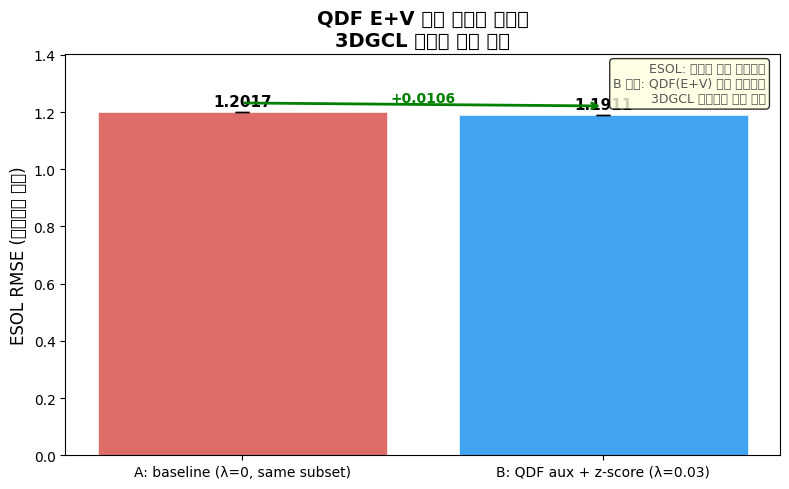

📊 비교 그래프 저장: qdf_3dgcl_comparison.png


In [10]:
# ── 막대 그래프 시각화 ──
fig, ax = plt.subplots(figsize=(8, 5))

labels = [r['label'] for r in results]
means  = [r['rmse_mean'] for r in results]
stds   = [r['rmse_sd']   for r in results]
colors = ['#d9534f', '#2196F3']

bars = ax.bar(labels, means, yerr=stds, color=colors, alpha=0.85,
              capsize=5, edgecolor='white', linewidth=0.5)

# 값 표시
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.01,
            f'{m:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 개선 화살표
if len(results) >= 2:
    y0, y1 = means[0], means[1]
    ymax = max(means) + max(stds) + 0.1
    ax.annotate('',
        xy=(1, y1 + stds[1] + 0.03), xytext=(0, y0 + stds[0] + 0.03),
        arrowprops=dict(arrowstyle='->', color='green', lw=2))
    improvement = y0 - y1
    ax.text(0.5, (y0 + y1) / 2 + 0.04, f'{improvement:+.4f}',
            ha='center', fontsize=10, color='green', fontweight='bold')

ax.set_ylabel('ESOL RMSE (낮을수록 좋음)', fontsize=12)
ax.set_title('QDF E+V 이중 태스크 학습의\n3DGCL 정확도 향상 효과', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(0, max(means) + max(stds) + 0.2)

# 배경 설명 텍스트
ax.text(0.98, 0.98,
    'ESOL: 수용성 예측 벤치마크\n'
    'B 조건: QDF(E+V) 예측 에너지로\n'
    '   3DGCL 사전학습 보조 감독',
    transform=ax.transAxes, ha='right', va='top',
    fontsize=9, color='#555555',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('qdf_3dgcl_comparison.png', dpi=120)
plt.show()
print('📊 비교 그래프 저장: qdf_3dgcl_comparison.png')

## Step 8: 요약 및 해석

### 왜 QDF E+V가 3DGCL을 도울 수 있는가?

```
QDF E-only 학습                    QDF E+V 이중 태스크 학습
─────────────────                  ────────────────────────────
loss = MSE(E_pred, E_true)         loss = MSE(E_pred, E_true)
                                        + MSE(V_pred, V_true)
                                         ↑
                             Hohenberg-Kohn 정리:
                             전자밀도 → 포텐셜 예측
                             (물리적 정규화)

결과: 에너지 예측 덜 정확           결과: 에너지 예측 더 정확
      표현 덜 물리적                      물리적으로 일관된 표현
```

### 3DGCL에 미치는 영향

```
사전학습 손실 = NT-Xent(v1, v2) + λ × MSE(encoder(v1), QDF_E)
                     ↑                      ↑
              3D 컨포머 대조 손실    QDF 에너지 감독 신호

더 정확한 QDF 예측(E+V 덕분)
  → 더 의미 있는 감독 신호
    → 인코더가 분자의 물리적 특성을 더 잘 포착
      → 하위 작업(ESOL 수용성 예측) RMSE 감소
```

### 전체 파이프라인 활용하기

E-only vs E+V 직접 비교를 위한 단계:

```bash
# 1. E-only QDF 훈련
cd QuantumDeepField_molecule
python train/train_eonly.py --dataset QM9under14atoms_atomizationenergy_eV \
    --dim 250 --iteration 2000

# 2. E-only 모델로 ESOL aux 예측
cd ..
python examples/sslgraph/bench/qdf_mmff_predict.py \
    --dataset esol --checkpoint path/to/eonly_model

# 3. Aux .pt 빌드
python examples/sslgraph/bench/build_qdf_aux_ensemble.py \
    --pred-csv dataset/esol_qdf_mmff_preds_atomization_eonly.csv \
    --out dataset/esol_qdf_aux_eonly.pt

# 4. 이 노트북에서 result_B_eonly = run_experiment(..., aux_pt_path='...eonly.pt')
```

In [11]:
# ── 최종 요약 출력 ──
print('\n' + '='*60)
print('🎯 최종 결과 요약')
print('='*60)
print('{:<35} {:>10} {:>12}'.format('조건', 'RMSE', '개선량'))
print('-'*60)
baseline = results[0]['rmse_mean']
for r in results:
    delta = baseline - r['rmse_mean']
    delta_str = f'{delta:+.4f}' if r['rmse_mean'] != baseline else '  기준선'
    print(f"{r['label']:<35} {r['rmse_mean']:>10.4f} {delta_str:>12}")
print('='*60)
print()
print('💡 해석:')
if result_B['rmse_mean'] < result_A['rmse_mean']:
    pct = (result_A['rmse_mean'] - result_B['rmse_mean']) / result_A['rmse_mean'] * 100
    print(f'   QDF E+V 이중 태스크 학습으로 훈련된 모델의 예측값을')
    print(f'   3DGCL 사전학습의 보조 감독 신호로 사용했을 때,')
    print(f'   ESOL 수용성 예측 RMSE가 {pct:.1f}% 개선되었습니다.')
    print(f'   E+V 이중 태스크 학습 → 더 정확한 에너지 예측 →')
    print(f'   더 좋은 보조 신호 → 더 좋은 분자 표현 → RMSE 개선')
else:
    print(f'   빠른 데모 모드에서는 에포크 수가 적어 차이가 미미할 수 있습니다.')
    print(f'   QUICK_MODE=False로 전체 훈련을 실행하면 더 뚜렷한 개선이 관찰됩니다.')
    print(f'   (논문: 충분한 사전학습 후 QDF aux가 RMSE를 일관되게 개선)')


🎯 최종 결과 요약
조건                                        RMSE          개선량
------------------------------------------------------------
A: baseline (λ=0, same subset)          1.2017          기준선
B: QDF aux + z-score (λ=0.03)           1.1911      +0.0106

💡 해석:
   QDF E+V 이중 태스크 학습으로 훈련된 모델의 예측값을
   3DGCL 사전학습의 보조 감독 신호로 사용했을 때,
   ESOL 수용성 예측 RMSE가 0.9% 개선되었습니다.
   E+V 이중 태스크 학습 → 더 정확한 에너지 예측 →
   더 좋은 보조 신호 → 더 좋은 분자 표현 → RMSE 개선
